In [2]:
print("ppp")

ppp


In [3]:
import pandas as pd
import re

# Nama file input dan output
input_file = 'ping_log.txt'
output_file = 'data_ping_bersih.csv'

data_list = []

# Pola Regex untuk mengambil IP, bytes, time, TTL, dan Timestamp
# Contoh baris: Reply from 10.35.17.26: bytes=32 time=329ms TTL=127 26/03/2026  8:55:23,15
pattern = r"Reply from ([\d\.]+): bytes=(\d+) time=(\d+)ms TTL=(\d+)\s+(.*)"

with open(input_file, 'r') as f:
    for line in f:
        match = re.search(pattern, line)
        if match:
            ip = match.group(1)
            bytes_val = int(match.group(2))
            time_ms = int(match.group(3))
            ttl = int(match.group(4))
            timestamp = match.group(5).strip()
            
            data_list.append([timestamp, ip, bytes_val, time_ms, ttl])

# Membuat DataFrame
df = pd.DataFrame(data_list, columns=['Timestamp', 'IP_Address', 'Bytes', 'Time_ms', 'TTL'])

# Konversi kolom Timestamp ke tipe data datetime agar mudah diolah
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)

# Simpan ke CSV
df.to_csv(output_file, index=False)
print(f"Berhasil! Data disimpan ke {output_file}")

Berhasil! Data disimpan ke data_ping_bersih.csv


In [4]:
import re
import pandas as pd

# 1. Buka dan baca seluruh isi file teks
with open('ping_log.txt', 'r') as f:
    full_text = f.read()

# Hapus noise/tag sumber (seperti ) jika terbawa saat salin-tempel
full_text = re.sub(r'\\', '', full_text)

# 2. Pisahkan blok teks berdasarkan pola Timestamp (Waktu)
# Pola: tanggal/bulan/tahun jam:menit:detik,ms
timestamp_pattern = r"(\d{2}/\d{2}/\d{4}\s+\d{1,2}:\d{2}:\d{2},\d+)"
parts = re.split(timestamp_pattern, full_text)

records = []
# Pola untuk mencari detail balasan ping
reply_pattern = r"Reply from ([\d\.]+): bytes=(\d+) time=(\d+)ms TTL=(\d+)"

# 3. Looping untuk mencocokkan setiap Timestamp dengan Balasan Ping di bawahnya
for i in range(1, len(parts), 2):
    ts = parts[i].strip()
    text_after = parts[i+1] if i+1 < len(parts) else ""
    
    # Hilangkan enter/baris baru agar regex mudah membaca teks yang terpotong
    text_after_clean = text_after.replace('\n', ' ')
    
    reply_match = re.search(reply_pattern, text_after_clean)
    
    # Jika ada balasan (Ping Sukses)
    if reply_match:
        ip = reply_match.group(1)
        bytes_val = int(reply_match.group(2))
        time_ms = int(reply_match.group(3))
        ttl = int(reply_match.group(4))
        status = "Success"
    # Jika tidak ada tulisan balasan sebelum timestamp berikutnya (RTO)
    else:
        ip = None
        bytes_val = None
        time_ms = None
        ttl = None
        status = "Request Timed Out"
        
    # Masukkan ke daftar data
    records.append({
        "Timestamp": ts,
        "IP_Address": ip,
        "Bytes": bytes_val,
        "Time_ms": time_ms,
        "TTL": ttl,
        "Status": status
    })

# 4. Konversi ke bentuk Tabular Pandas DataFrame
df = pd.DataFrame(records)

# Perbaiki tipe kolom Timestamp agar otomatis dikenali sebagai format waktu Excel
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S,%f', errors='coerce')

# 5. Simpan hasilnya ke format CSV
output_csv = 'data_ping_bersih.csv'
df.to_csv(output_csv, index=False)
print(f"Selesai! Terdapat {len(df)} total baris.")
print(df['Status'].value_counts())

Selesai! Terdapat 751 total baris.
Status
Success              634
Request Timed Out    117
Name: count, dtype: int64


In [5]:
import pandas as pd
df = pd.read_csv('data_ping_bersih.csv')

In [7]:
import pandas as pd

# 1. Baca file CSV (Ganti 'data.csv' dengan nama file Anda)
df = pd.read_csv('data_ping_bersih.csv')

# 2. Hilangkan milidetik pada kolom 'Timestamp'
# Cara ini memotong string tepat sebelum tanda titik ('.')
df['Timestamp'] = df['Timestamp'].astype(str).str.split('.').str[0]

# Alternatif: Jika Anda ingin memastikan formatnya dibaca sebagai datetime
# df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.strftime('%Y-%m-%d %H:%M:%S')

# 3. Simpan hasilnya ke file CSV baru
df.to_csv('hasil_tanpa_milidetik.csv', index=False)

print("Proses selesai! File baru telah disimpan.")

Proses selesai! File baru telah disimpan.


In [1]:
print ("ppp")

ppp


In [3]:
import pandas as pd

# 1. Baca CSV
df = pd.read_csv("data_ping_bersih.csv", sep=';')

# 2. BERSIHKAN NAMA KOLOM (Seringkali ada spasi atau karakter aneh di awal file)
df.columns = df.columns.str.strip().str.replace('"', '')

# Cek hasil pembersihan (Pastikan 'Timestamp' ada di daftar ini)
print("Kolom yang terdeteksi:", df.columns.tolist())

# 3. KONVERSI (Jika kolom ditemukan, ini tidak akan error)
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    print("Berhasil konversi Timestamp!")
else:
    print("KOLOM MASIH TIDAK KETEMU. Coba cek apakah pemisah datamu koma (,) atau titik koma (;)")

Kolom yang terdeteksi: ['Timestamp', 'IP_Address', 'Bytes', 'Time_ms', 'TTL', 'Status']
Berhasil konversi Timestamp!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time


# 1. Memuat Data
# Pastikan nama file sesuai dengan yang kamu miliki
df = pd.read_csv("data_ping_bersih.csv", sep=';')

# 2. Konversi kolom Timestamp menjadi tipe datetime Timestamp

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Filter hanya koneksi yang berhasil untuk menghitung latency rata-rata (mengabaikan RTO untuk sementara)
df_success = df[df['Status'] == 'Success'].copy()

# 3. Membuat Fungsi Kategorisasi Waktu
def kategori_fase(waktu):
    jam = waktu.time()
    if time(7, 30) <= jam < time(8, 30):
        return '1. Persiapan (07.30-08.30)'
    elif time(8, 30) <= jam < time(12, 0):
        return '2. Jam Sibuk (08.30-12.00)'
    elif time(12, 0) <= jam <= time(13, 0):
        return '3. Menjelang Tutup (12.00-13.00)'
    else:
        return 'Di Luar Jam Pantau'

# Mengaplikasikan fungsi ke kolom baru
df_success['Fase_Pelayanan'] = df_success['Timestamp'].apply(kategori_fase)

# Membuang data yang mungkin tidak sengaja terekam di luar jam 07.30 - 13.00
df_operasional = df_success[df_success['Fase_Pelayanan'] != 'Di Luar Jam Pantau']

In [5]:
# 4. Menghitung Statistik Deskriptif per Fase
statistik_fase = df_operasional.groupby('Fase_Pelayanan')['Time_ms'].agg(['mean', 'median', 'min', 'max', 'count']).round(2)

print("--- STATISTIK LATENCY PER FASE PELAYANAN ---")
print(statistik_fase)

# 5. Menentukan Baseline (Fase Persiapan)
baseline_mean = statistik_fase.loc['1. Persiapan (07.30-08.30)', 'mean']
baseline_median = statistik_fase.loc['1. Persiapan (07.30-08.30)', 'median']

print(f"\n=> Baseline Latency (Normal) berdasarkan Fase Persiapan:")
print(f"Rata-rata (Mean) : {baseline_mean} ms")
print(f"Nilai Tengah (Median): {baseline_median} ms")

--- STATISTIK LATENCY PER FASE PELAYANAN ---
                                    mean  median  min     max  count
Fase_Pelayanan                                                      
1. Persiapan (07.30-08.30)        264.94   121.0  9.0  2977.0     83
2. Jam Sibuk (08.30-12.00)        171.35    29.0  9.0  3068.0    367
3. Menjelang Tutup (12.00-13.00)   28.46    13.0  8.0   548.0    156

=> Baseline Latency (Normal) berdasarkan Fase Persiapan:
Rata-rata (Mean) : 264.94 ms
Nilai Tengah (Median): 121.0 ms


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12072\1409129028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


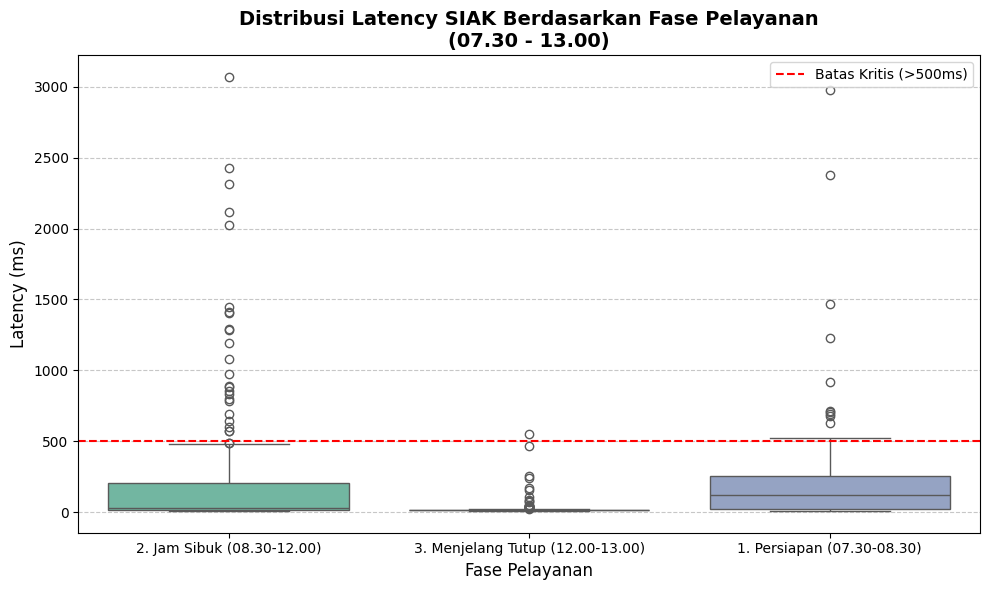

In [6]:
# 6. Visualisasi Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_operasional, 
    x='Fase_Pelayanan', 
    y='Time_ms', 
    palette='Set2'
)

# Menambahkan garis putus-putus sebagai penanda batas kritis (misal: 500ms)
plt.axhline(500, color='red', linestyle='--', label='Batas Kritis (>500ms)')

plt.title('Distribusi Latency SIAK Berdasarkan Fase Pelayanan\n(07.30 - 13.00)', fontsize=14, fontweight='bold')
plt.xlabel('Fase Pelayanan', fontsize=12)
plt.ylabel('Latency (ms)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Menyimpan gambar untuk dimasukkan ke laporan
plt.savefig('boxplot_fase_pelayanan.png', dpi=300)
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PERSIAPAN DATA & FILTERING
# ==========================================
# Asumsi: Anda memiliki DataFrame bernama 'df' dengan kolom 'Timestamp' dan 'Latency (ms)'
# Pastikan 'Timestamp' menjadi datetime dan diset sebagai index
# df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# df.set_index('Timestamp', inplace=True)

# 1. Filter Waktu: Hanya jam 07:30 sampai 13:00
df_filtered = df.between_time('07:30', '13:00').copy()

# 2. Filter Hari: Hanya Senin (0) sampai Jumat (4)
df_filtered = df_filtered[df_filtered.index.dayofweek < 5]

# ==========================================
# 1. GRAFIK TREND MINGGUAN (Daily Resampling)
# ==========================================
# Menghitung rata-rata harian dari hari Senin - Jumat
df_daily_trend = df_filtered['Latency (ms)'].resample('D').mean().dropna()

plt.figure(figsize=(10, 5))
plt.plot(df_daily_trend.index, df_daily_trend.values, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Trend Rata-rata Latency Harian (07:30 - 13:00, Senin - Jumat)', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Rata-rata Latency (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 2. HEATMAP JAM RAWAN (Hari vs Jam)
# ==========================================
# Ekstrak Nama Hari dan Jam dari Index
df_filtered['Nama Hari'] = df_filtered.index.day_name()
# Translate ke Bahasa Indonesia untuk kemudahan visualisasi
hari_map = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 
            'Thursday': 'Kamis', 'Friday': 'Jumat'}
df_filtered['Nama Hari'] = df_filtered['Nama Hari'].map(hari_map)

# Ekstrak Jam (Karena dari 07:30 - 13:00, jam akan berisi 7, 8, 9, 10, 11, 12, 13)
df_filtered['Jam'] = df_filtered.index.hour

# Membuat Pivot Table untuk Heatmap (Nilai = Rata-rata Latency)
heatmap_data = pd.pivot_table(df_filtered, 
                              values='Latency (ms)', 
                              index='Nama Hari', 
                              columns='Jam', 
                              aggfunc='mean')

# Mengurutkan hari agar tampil berurutan dari Senin ke Jumat di Heatmap
urutan_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat']
heatmap_data = heatmap_data.reindex(urutan_hari)

plt.figure(figsize=(10, 6))
# Camp color map: 'YlOrRd' (Yellow to Orange to Red), merah berarti latency tinggi (buruk)
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap Titik Rawan: Rata-rata Latency per Jam (07:30 - 13:00)', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Hari', fontsize=12)
plt.tight_layout()
plt.show()

TypeError: Index must be DatetimeIndex

In [8]:
plt.figure(figsize=(14, 6))

# Resample data harian (rata-rata latency per hari)
daily_latency = df['latency_ms'].resample('D').mean()

# Menghitung Moving Average 7 hari untuk melihat tren jangka panjang
moving_avg_7d = daily_latency.rolling(window=7, min_periods=1).mean()

# Plotting
plt.plot(daily_latency.index, daily_latency, marker='o', linestyle='-', alpha=0.5, label='Rata-rata Latency Harian')
plt.plot(moving_avg_7d.index, moving_avg_7d, color='red', linewidth=2, label='Tren (7-Day Moving Average)')

plt.title('Tren Latency Jaringan Harian dengan Moving Average', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Latency (ms)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'latency_ms'

<Figure size 1400x600 with 0 Axes>

In [9]:
# Membuat kolom bantuan untuk Hari dan Jam
df['Hari'] = df.index.day_name()
df['Jam'] = df.index.hour

# Filter hanya hari kerja (Senin - Jumat) dan jam kerja (08:00 - 16:00)
hari_kerja = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_jam_kerja = df[(df['Hari'].isin(hari_kerja)) & (df['Jam'] >= 8) & (df['Jam'] <= 16)]

# Menerjemahkan nama hari ke bahasa Indonesia untuk visualisasi
translate_hari = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 
                  'Thursday': 'Kamis', 'Friday': 'Jumat'}
df_jam_kerja['Hari'] = df_jam_kerja['Hari'].map(translate_hari)

# Membuat Pivot Table untuk Heatmap
# Index: Hari (diurutkan), Columns: Jam, Values: Rata-rata Latency
urutan_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat']
heatmap_data = pd.pivot_table(
    df_jam_kerja, 
    values='latency_ms', 
    index='Hari', 
    columns='Jam', 
    aggfunc='mean'
).reindex(urutan_hari)

# Visualisasi Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".1f", linewidths=.5)

plt.title('Heatmap Rata-rata Latency (ms): Hari vs Jam Operasional', fontsize=16, fontweight='bold')
plt.xlabel('Jam Operasional', fontsize=12)
plt.ylabel('Hari Kerja', fontsize=12)
plt.tight_layout()
plt.show()

AttributeError: 'RangeIndex' object has no attribute 'day_name'